In [4]:
import torch

# Example shapes
B = 2   # Batch size
N = 4   # Size of y

# Random tensor inputs
x = torch.tensor([[1, 2, 3], [4, 5, 6]])  # Shape: (B x 3)
y = torch.tensor([2, 4, 6, 8])     # Shape: (N)

# Reshape x to (B, 3, 1) to allow broadcasting along the last dimension (for multiplication with y)
x_expanded = x.unsqueeze(2)  # Shape: (B, 3, 1)

# Reshape y to (1, N) to broadcast across the batch and 3 dimensions
y_expanded = y.unsqueeze(0)  # Shape: (1, N)

# Multiply using broadcasting and reshape to (B, 3 * N)
output = (x_expanded * y_expanded).view(B, 3 * N)

print(output.shape)  # Should be (B, 3 * N)


torch.Size([2, 12])


In [5]:
import torch
import torch.nn as nn

def get_rays(H, W, K, c2w):
    i, j = torch.meshgrid(torch.linspace(0, W-1, W), torch.linspace(0, H-1, H))  # pytorch's meshgrid has indexing='ij'
    i = i.t()
    j = j.t()
    dirs = torch.stack([(i-K[0][2])/K[0][0], -(j-K[1][2])/K[1][1], -torch.ones_like(i)], -1)
    # Rotate ray directions from camera frame to the world frame
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)  # dot product, equals to: [c2w.dot(dir) for dir in dirs]
    # Translate camera frame's origin to the world frame. It is the origin of all rays.
    rays_o = c2w[:3,-1].expand(rays_d.shape)
    return rays_o, rays_d



In [6]:
from tqdm import tqdm
a = [1, 2, 3]
b = tqdm(a)

  0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
for i in b:
    print(i)
    import time
    time.sleep(1)

1


 33%|███▎      | 1/3 [00:01<00:02,  1.01s/it]

2


In [19]:
import numpy as np
a = np.load("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/fern/poses_bounds.npy")

In [28]:
a[-1][-2:]

array([17.54252011, 76.71614081])

In [3]:
import imageio

In [5]:
a = ['/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/horns/images/DJI_20200223_163017_967.jpg',
 '/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/horns/images/DJI_20200223_163017_967.jpg',]

In [1]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from datasets.llff_dataset import LLFFDataset

In [2]:
config = {
    'base_dir': '/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/horns',
    'image_preload': False,
    'image_folder': 'images',
    'factor': 8
}

In [3]:
dset = LLFFDataset(config)

Warning! boundary_factor is not provided. No scaling will be applied.


/home/diya/anaconda3/envs/tensorRT_JY/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Warning! n_sample_rays is not provided. Using all rays.


In [5]:
dset.coords.shape

torch.Size([62, 12192768, 2])

In [6]:
from torch.utils.data import DataLoader

dl = DataLoader(dset, batch_size=2, shuffle=False)

In [8]:
for img, pose, c2w, near, far in dl:
    print(img.shape, pose.shape, c2w.shape, near, far)

torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[16.2330],
        [16.2131]]) tensor([[146.3064],
        [153.8633]])
torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[16.2412],
        [16.2190]]) tensor([[141.0108],
        [171.8516]])
torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[16.3146],
        [16.2165]]) tensor([[172.6000],
        [177.4050]])
torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[16.1921],
        [16.4644]]) tensor([[174.5868],
        [168.4688]])
torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[16.2197],
        [15.6226]]) tensor([[169.8272],
        [171.7514]])
torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[15.1949],
        [15.2344]]) tensor([[174.5742],
        [174.0379]])
torch.Size([2, 3, 378, 504]) torch.Size([2, 3, 4]) torch.Size([2, 3, 5]) tensor([[

KeyboardInterrupt: 

In [1]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from nerf.models import nerf
from nerf.models import build_model
from nerf.engines import build_engine
import torch

In [4]:
# model = nerf.NeRF()
cfg = {
    'name': 'basic_nerf'
}
model = build_model(cfg, {})

In [6]:
model.to('cuda:0')

NeRF(
  (xyz_embedding): SinusoidalEmbedding()
  (direction_embedding): SinusoidalEmbedding()
  (body): MLP(
    (layer): ModuleList(
      (0): Linear(in_features=60, out_features=256, bias=True)
      (1-3): 3 x Linear(in_features=256, out_features=256, bias=True)
      (4): Linear(in_features=316, out_features=256, bias=True)
      (5-7): 3 x Linear(in_features=256, out_features=256, bias=True)
    )
    (act_fn): ReLU()
  )
  (RGB_layer): MLP(
    (layer): ModuleList(
      (0): Linear(in_features=280, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=3, bias=True)
    )
    (act_fn): ReLU()
  )
  (sigma_layer): Linear(in_features=256, out_features=1, bias=True)
)

In [12]:
list(model.xyz_embedding.parameters())

[]

In [6]:
cfg = {
    'model': 'basic_nerf',
    'loss_fn': 'l2',
    'optimizer': 'adam',
    'optimizer_params': {
        'lr': 1e-4
    },
    'scheduler': 'none',
    'num_epochs': 100,
    'batch_size': 2,
    'verbose': True 
}

In [7]:
build_engine(cfg)

In [3]:
B = 2
xyz_dim = 3
direc_dim = 3

xyz = torch.randn((B, xyz_dim))
direc = torch.randn((B, direc_dim))

rgb, sigma = model(xyz, direc)
rgb.shape, sigma.shape

(torch.Size([2, 3]), torch.Size([2, 1]))

In [4]:
from nerf.nn.embedding import SinusoidalEmbedding

In [13]:
xyz_emb = SinusoidalEmbedding(10)
direc_emb = SinusoidalEmbedding(4)

In [14]:
xyz = torch.randn((B, xyz_dim))
direc = torch.randn((B, direc_dim))

xyz_emb(xyz).shape, direc_emb(direc).shape

(torch.Size([2, 60]), torch.Size([2, 24]))

In [15]:
model.body(xyz_emb(xyz))

tensor([[-5.1363e+00,  2.5150e+00, -2.7562e+00, -9.1840e-01, -4.5457e-01,
          3.1289e+00, -8.8021e-01, -2.4128e+00, -5.8698e+00, -2.1292e+00,
          6.1760e+00, -1.3049e+00, -1.6112e+00, -5.4928e+00,  4.0487e-01,
         -7.3976e+00,  3.2872e+00,  1.5190e-01,  2.8788e+00, -1.7701e+00,
         -8.7420e-01,  1.5764e+00, -3.0872e+00, -1.9115e+00, -2.4268e+00,
         -2.7500e+00, -3.2190e+00,  3.1970e+00,  7.1609e-01, -7.1619e+00,
          5.1797e+00, -4.4653e+00,  2.8353e+00,  4.7283e+00, -2.7248e+00,
         -3.8625e+00,  7.9343e-01, -7.2049e-01, -2.0904e-01, -2.4072e+00,
         -1.1386e+00, -1.7711e+00, -1.8680e+00,  1.7447e+00,  1.1677e+00,
         -3.8115e+00, -7.2147e-01,  3.5562e+00, -3.2984e+00, -6.4195e-01,
         -2.5895e+00,  2.0734e+00, -4.5367e+00, -6.2839e+00,  4.0954e+00,
         -5.4798e+00,  3.5472e+00,  8.0868e+00,  2.3882e+00,  7.2533e+00,
          6.0263e+00,  3.2202e+00,  3.5412e+00, -2.3060e+00,  9.2795e-01,
          1.4782e+00, -1.6994e-01, -2.

In [2]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from nerf.ray import get_rays

In [5]:
import torch
H = 30
W = 40
K = torch.tensor([[1, 0, 15], [0, 1, 20], [0, 0, 1]])
c2w = torch.eye(4)
out = get_rays(H, W, K, c2w)

In [16]:
out[1].shape

torch.Size([30, 40, 3])

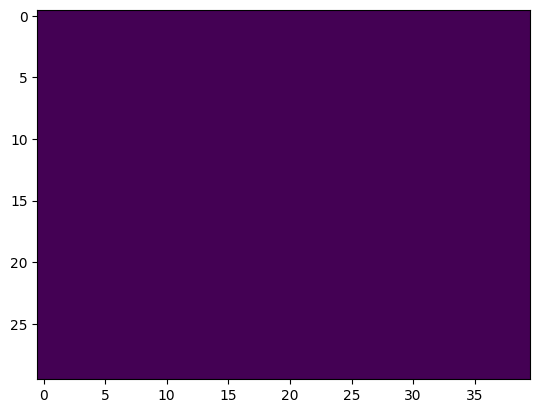

In [20]:
import matplotlib.pyplot as plt

plt.imshow(out[1][:, :, 2])

In [12]:
import torch

t_vals = torch.linspace(0., 1., steps=10)
lindisp = False

near = 1
far = 3

if not lindisp:
    z_vals = near * (1.-t_vals) + far * (t_vals)
else:
    z_vals = 1./(1./near * (1.-t_vals) + 1./far * (t_vals))
    
    
print(z_vals)

tensor([1.0000, 1.2222, 1.4444, 1.6667, 1.8889, 2.1111, 2.3333, 2.5556, 2.7778,
        3.0000])


In [15]:
z_vals.shape

torch.Size([10])

In [17]:
z_vals.expand([2, 10]) == torch.stack([z_vals for _ in range(2)])

tensor([[True, True, True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True]])

In [18]:
import torch

t_vals = torch.linspace(0., 1., steps=11)
lindisp = True
print(t_vals.shape)

near = 1
far = 3

if not lindisp:
    z_vals = near * (1.-t_vals) + far * (t_vals)
else:
    z_vals = 1./(1./near * (1.-t_vals) + 1./far * (t_vals))
    
    
print(z_vals)

torch.Size([11])
tensor([1.0000, 1.0714, 1.1538, 1.2500, 1.3636, 1.5000, 1.6667, 1.8750, 2.1429,
        2.5000, 3.0000])


In [1]:
import torch


torch.stack([torch.randn((3, 2, 1)) for _ in range(7)]).shape

torch.Size([7, 3, 2, 1])